In [4]:
import sys

!{sys.executable} -m pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [1]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [16]:
import pandas as pd

path = r"F:\ERP_data\final_corpusRCRS_clean.jsonl"

df = pd.read_json(
    path,
    lines=True
)

text = df['text_for_analysis']

In [17]:
# calculate sentiment score
def vader_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score


sentiment_scores = df['text_for_analysis'].apply(vader_sentiment)

sentiment_df = pd.DataFrame(sentiment_scores.tolist())


df = pd.concat([df, sentiment_df], axis=1)

In [18]:
# sentiment label
def sentiment_label(compound):
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

df['sentiment_label'] = df['compound'].apply(sentiment_label)

df['sentiment_label'].value_counts()

sentiment_label
positive    1392
negative     718
neutral      294
Name: count, dtype: int64

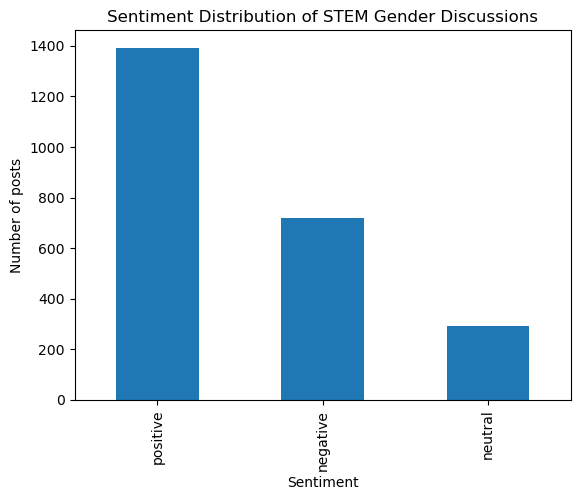

In [13]:
# EDA: Overall sentiment distribution
import matplotlib.pyplot as plt

ax = df['sentiment_label'].value_counts().plot(
    kind='bar')

plt.xlabel("Sentiment")
plt.ylabel("Number of posts")
plt.title("Sentiment Distribution of STEM Gender Discussions")
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

In [19]:
# compare sub and com
sentiment_prop = (
    pd.crosstab(
        df['source_type'],
        df['sentiment_label'],
        normalize='index'
    )
)

(sentiment_prop * 100).round(2)

sentiment_label,negative,neutral,positive
source_type,,,
comment,31.61,9.33,59.07
submission,22.78,24.05,53.16


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = r"F:\ERP_data\final_corpusRCRS_topic_sentiment.jsonl"

df = pd.read_json(
    file_path,
    lines=True
)

print(df.shape)
print(df[['source_type', 'sentiment_label']].head())

(2404, 99)
  source_type sentiment_label
0     comment        positive
1     comment        positive
2     comment        positive
3     comment        negative
4     comment        positive


In [2]:
sentiment_prop = pd.crosstab(
    df['source_type'],
    df['sentiment_label'],
    normalize='index'
) * 100

sentiment_prop = sentiment_prop[
    ['negative', 'neutral', 'positive']
]

sentiment_prop.round(2)

sentiment_label,negative,neutral,positive
source_type,,,
comment,31.61,9.33,59.07
submission,22.78,24.05,53.16


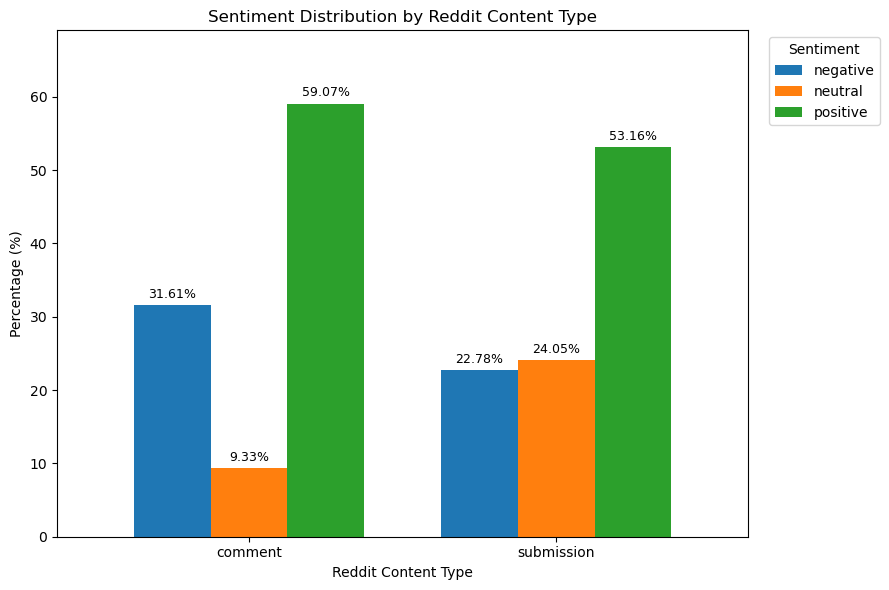

In [4]:
ax = sentiment_prop.plot(
    kind='bar',
    stacked=False,
    figsize=(9, 6),
    width=0.75
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.xlabel("Reddit Content Type")
plt.ylabel("Percentage (%)")

plt.title(
    "Sentiment Distribution by Reddit Content Type"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.ylim(
    0,
    sentiment_prop.max().max() + 10
)

plt.tight_layout()

plt.show()

In [20]:
df.groupby('source_type')['compound'].mean()

source_type
comment       0.221813
submission    0.251253
Name: compound, dtype: float64

In [6]:
# Chi-square to test sentiment distribution is independent of source type
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['source_type'],
    df['sentiment_label']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 79.66566073894694
p-value: 5.021362465851196e-18
